Conditionally IID Observations

In [ ]:
!pip uninstall tensorflow

In [ ]:
!pip install tensorflow-gpu==2.0.0-alpha0

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.0.0-alpha0


In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.layers import Input, LSTM, Dense, Reshape

In [ ]:
input_dim = 7 # input dimensionality
mu_pre = np.zeros(input_dim) # pre-change mean
mu_post = np.ones(input_dim) # post-change mean

In [ ]:
# Training Data
batch_size = 32
num_batch = 100
data_size = batch_size * num_batch # number of data streams in the training data
timesteps = 2000 # length of a training data stream 
rho = 0.001 # geometric parameter
pre_label = np.array([0])
post_label = np.array([1])

x_train = []
y_train = []
for jj in range(data_size):
    tau = np.random.geometric(rho) # random change-point
    if tau > timesteps:
        data_i = mu_pre + np.random.randn(1,timesteps,input_dim)
        label_i = pre_label + np.zeros([1,timesteps,1])
    else:
        data_pre = mu_pre + np.random.randn(1,tau-1,input_dim)  
        data_post = mu_post + np.random.randn(1,timesteps-tau+1,input_dim) 
        data_i = np.concatenate((data_pre,data_post),axis=1)
        label_pre = pre_label + np.zeros([1,tau-1,1])
        label_post = post_label + np.zeros([1,timesteps-tau+1,1])
        label_i = np.concatenate((label_pre,label_post),axis=1)

    if x_train == []:
        x_train = data_i
    else:    
        x_train = np.concatenate((x_train,data_i),axis=0)

    if y_train == []:
        y_train = label_i 
    else:
        y_train = np.concatenate((y_train,label_i),axis=0)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:24: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:29: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.


In [ ]:
print(x_train.shape)
print(y_train.shape)

(3200, 2000, 7)
(3200, 2000, 1)


In [ ]:
# Validation Data
val_size = 500
val_data_pre = mu_pre + np.random.randn(val_size,timesteps//2,input_dim) # for the validation data, assume a fixed change-point: tau = timesteps/2
val_data_post = mu_post + np.random.randn(val_size,timesteps//2,input_dim)
x_val = np.concatenate((val_data_pre,val_data_post),axis=1)

y_pre_val = pre_label + np.zeros([val_size,timesteps//2,1])
y_post_val = post_label + np.zeros([val_size,timesteps//2,1])
y_val = np.concatenate((y_pre_val,y_post_val),axis=1)

In [ ]:
# Build the Neural Network
model = tf.keras.Sequential() 
model.add(Input(shape=(timesteps,input_dim))) 
model.add(LSTM(16, return_sequences = True))  
model.add(Dense(10, activation='relu')) 
model.add(Dense(1, activation='sigmoid'))
model.summary() 

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
unified_lstm (UnifiedLSTM)   (None, 2000, 16)          1536      
_________________________________________________________________
dense (Dense)                (None, 2000, 10)          170       
_________________________________________________________________
dense_1 (Dense)              (None, 2000, 1)           11        
Total params: 1,717
Trainable params: 1,717
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Offline Training Phase
history = model.fit(x_train, y_train,
          validation_data=(x_val, y_val),
          batch_size=batch_size,
          epochs=20)

Train on 3200 samples, validate on 500 samples
Epoch 1/20
3200/3200 [==============================] - 13s 4ms/sample - loss: 0.2882 - accuracy: 0.8735 - val_loss: 0.1056 - val_accuracy: 0.9934
Epoch 2/20
3200/3200 [==============================] - 6s 2ms/sample - loss: 0.0363 - accuracy: 0.9962 - val_loss: 0.0182 - val_accuracy: 0.9968
Epoch 3/20
3200/3200 [==============================] - 6s 2ms/sample - loss: 0.0128 - accuracy: 0.9976 - val_loss: 0.0116 - val_accuracy: 0.9976
Epoch 4/20
3200/3200 [==============================] - 7s 2ms/sample - loss: 0.0091 - accuracy: 0.9981 - val_loss: 0.0089 - val_accuracy: 0.9981
Epoch 5/20
3200/3200 [==============================] - 6s 2ms/sample - loss: 0.0073 - accuracy: 0.9984 - val_loss: 0.0074 - val_accuracy: 0.9984
Epoch 6/20
3200/3200 [==============================] - 6s 2ms/sample - loss: 0.0062 - accuracy: 0.9986 - val_loss: 0.0065 - val_accuracy: 0.9985
Epoch 7/20
3200/3200 [==============================] - 6s 2ms/sample - loss

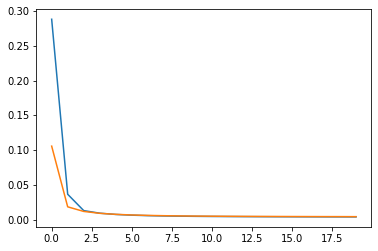

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
model2 = tf.keras.Sequential()  # model2 has the same structure and weights with the trained network  
model2.add(Input(shape=(1,input_dim), batch_size=1)) # only difference is it takes single input a time, as usual in online stream processing
model2.add(LSTM(16, return_sequences = True, stateful=True))  # we have an explicit control on the internal RNN state: the RNN state is going to be reset for each new data stream       
model2.add(Dense(10, activation='relu')) 
model2.add(Dense(1, activation='sigmoid')) 
model2.summary() 

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
unified_lstm_1 (UnifiedLSTM) (1, 1, 16)                1536      
_________________________________________________________________
dense_2 (Dense)              (1, 1, 10)                170       
_________________________________________________________________
dense_3 (Dense)              (1, 1, 1)                 11        
Total params: 1,717
Trainable params: 1,717
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model2.set_weights(model.get_weights()) 

**Performance Evaluation** **(Online Detection Phase)**

1) Bayesian Setting

In [ ]:
# Performance Evaluation (Data-Driven QCD Procedure & Shiryaev Algorithm) 
test_size = 10000 # number of experiments  
h_vec = np.append(np.linspace(0.01,0.99,50),0.995) # test thresholds
num_false_alarm_events = np.zeros(len(h_vec)) # number of false alarm events at each threshold over all experiments for the data-driven procedure
total_det_delays = np.zeros(len(h_vec)) # sum of all detection delays at each threshold over all experiments for the data-driven procedure
shiryaev_false_alarm_events = np.zeros(len(h_vec)) # same for the Shiryaev algorithm
shiryaev_det_delays = np.zeros(len(h_vec))
for jj in range(test_size):
    if jj % 100 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    tau = np.random.geometric(rho) # random change-point
    model2.reset_states() # reset the internal RNN state for the new experiment
    alarm_flag_vec = np.zeros(len(h_vec)) # alarm flags
    shiryaev_flag_vec = np.zeros(len(h_vec)) 
    p = 0 # reset the Shiryaev state   
    # new experiment
    while alarm_flag_vec[-1] == 0 or shiryaev_flag_vec[-1] == 0:
        t += 1
        # observation at time t
        if t < tau:
            data_t = mu_pre + np.random.randn(1,1,input_dim)
        else:
            data_t = mu_post + np.random.randn(1,1,input_dim)
        # decision statistic of the data-driven procedure
        dec_stat = model2.predict(data_t) 
        dec_stat = dec_stat[0][0][0]
        # Shiryaev algorithm: update the state and the decision statistic
        p_til = p + (1-p)*rho
        LR = np.exp(0.5*(np.matmul(data_t[0][0],np.transpose(data_t[0][0])) - np.matmul((data_t[0][0]-mu_post),np.transpose(data_t[0][0]-mu_post)))) # likelihood ratio
        p = (p_til*LR)/(p_til*LR + (1-p_til)) 
        # update the alarm flags, the false alarm events, and the detection delays
        if t < tau:
            # data-driven procedure
            num_false_alarm_events += (alarm_flag_vec == 0)*(dec_stat >= h_vec)
            alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec) 
            # Shiryaev algorithm
            shiryaev_false_alarm_events += (shiryaev_flag_vec == 0)*(p >= h_vec)
            shiryaev_flag_vec += (shiryaev_flag_vec == 0)*(p >= h_vec) 
        else:
            # data-driven procedure
            total_det_delays += (t-tau)*(alarm_flag_vec == 0)*(dec_stat >= h_vec)
            alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec)
            # Shiryaev algorithm
            shiryaev_det_delays += (t-tau)*(shiryaev_flag_vec == 0)*(p >= h_vec)
            shiryaev_flag_vec += (shiryaev_flag_vec == 0)*(p >= h_vec)

# compute the probability of false alarm (pfa) and average detection delay (add) over all experiments
pfa_vec = num_false_alarm_events/test_size
add_vec = total_det_delays/test_size
shiryaev_pfa_vec = shiryaev_false_alarm_events/test_size
shiryaev_add_vec = shiryaev_det_delays/test_size

In [ ]:
pfa_vec

array([9.98943077e-01, 9.98943077e-01, 9.98943077e-01, 9.98943077e-01,
       9.98943077e-01, 9.98943077e-01, 9.98490110e-01, 9.95772309e-01,
       9.88071871e-01, 9.66480447e-01, 9.20126831e-01, 8.53993658e-01,
       7.78046203e-01, 6.96210177e-01, 6.18903820e-01, 5.52166692e-01,
       5.02642307e-01, 4.57043636e-01, 4.22769138e-01, 3.90608486e-01,
       3.58598822e-01, 3.31420806e-01, 3.05601691e-01, 2.81141477e-01,
       2.61663899e-01, 2.43545221e-01, 2.24973577e-01, 2.07307867e-01,
       1.92057980e-01, 1.76808093e-01, 1.62011173e-01, 1.49177110e-01,
       1.34682168e-01, 1.19885248e-01, 1.10523932e-01, 1.00407670e-01,
       9.19522875e-02, 8.16850370e-02, 7.24747093e-02, 6.52272384e-02,
       5.76777895e-02, 4.96753737e-02, 4.12199909e-02, 3.39725200e-02,
       2.71780160e-02, 2.11384569e-02, 1.58538427e-02, 1.04182395e-02,
       5.13362525e-03, 1.50988978e-03, 1.50988978e-04])

In [ ]:
add_vec

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 6.03955911e-04, 2.71780160e-03,
       1.05692284e-02, 3.36705421e-02, 8.80265741e-02, 1.70919523e-01,
       2.71931149e-01, 3.80492224e-01, 4.97206704e-01, 5.90970859e-01,
       6.72504907e-01, 7.49509286e-01, 8.10508833e-01, 8.69998490e-01,
       9.28431225e-01, 9.82032312e-01, 1.03699230e+00, 1.09240525e+00,
       1.14192964e+00, 1.18707534e+00, 1.23675072e+00, 1.28506719e+00,
       1.33474256e+00, 1.37943530e+00, 1.42639287e+00, 1.46957572e+00,
       1.51759022e+00, 1.56605768e+00, 1.60531481e+00, 1.65136645e+00,
       1.69168051e+00, 1.74075193e+00, 1.79495697e+00, 1.84553828e+00,
       1.90457497e+00, 1.96889627e+00, 2.03457648e+00, 2.09874679e+00,
       2.18073381e+00, 2.28446323e+00, 2.39332629e+00, 2.53329307e+00,
       2.75418994e+00, 3.19824853e+00, 3.51864714e+00])

In [ ]:
shiryaev_pfa_vec

array([0.95032463, 0.87679299, 0.80854598, 0.74875434, 0.6945493 ,
       0.6478937 , 0.60335196, 0.56137702, 0.52483769, 0.49056319,
       0.45583572, 0.42760079, 0.40117771, 0.37505662, 0.35376717,
       0.33036388, 0.31164125, 0.29306961, 0.27691379, 0.26317379,
       0.24807489, 0.23508984, 0.21878303, 0.20368413, 0.18979315,
       0.17726106, 0.1671448 , 0.15582063, 0.14238261, 0.13105843,
       0.12139514, 0.11278877, 0.10569228, 0.09738789, 0.0904424 ,
       0.08485581, 0.07775932, 0.06975691, 0.06235845, 0.05646988,
       0.05224219, 0.04574966, 0.03744527, 0.03246263, 0.02944285,
       0.0232523 , 0.01796769, 0.01328703, 0.00770044, 0.00196286,
       0.00120791])

In [ ]:
shiryaev_add_vec

array([0.01766571, 0.06975691, 0.13770195, 0.21138457, 0.27389401,
       0.33881927, 0.40721727, 0.47380341, 0.52619659, 0.58402537,
       0.64487392, 0.69741809, 0.75026423, 0.79737279, 0.84176355,
       0.89430772, 0.94141628, 0.98459912, 1.02295032, 1.0602446 ,
       1.10327646, 1.14011777, 1.17997886, 1.22104786, 1.26226785,
       1.30333686, 1.33806432, 1.37324475, 1.41355881, 1.45311792,
       1.48935528, 1.52438472, 1.55956515, 1.60093613, 1.63943832,
       1.67371282, 1.71010116, 1.75569983, 1.79601389, 1.83587498,
       1.87890684, 1.92435452, 1.98097539, 2.04363581, 2.10312547,
       2.17877095, 2.27600785, 2.38970255, 2.54295636, 2.87105541,
       3.07685339])

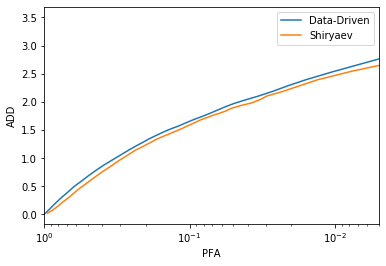

In [ ]:
plt.plot(pfa_vec,add_vec)
plt.plot(shiryaev_pfa_vec,shiryaev_add_vec)  
plt.xlim(1, 0.005) 
plt.xlabel("PFA")
plt.ylabel("ADD")
plt.xscale('log') 
plt.legend(["Data-Driven","Shiryaev"])